In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import duckdb 

In [2]:
import os
os.getcwd()

'/Users/zakariaabdullahi/Documents/crypto-dashboard-DE25-UX25/eda'

In [3]:
df = pd.read_csv("../data/interim/master_cleaned.csv")
df["date"] = pd.to_datetime(df["date"])

- EDA 1 
 - Volitilaty: Mesauring the how the prise sways daily.
High Volitilaty = High Risk

In [4]:
# Standard Deviation of daily returns as a measure of thee volatility
vol = (
    df.groupby("coin_id")["daily_return_pct"]
    .std()
    .reset_index()
    .sort_values("daily_return_pct", ascending=False)
)
vol



,coin_id,daily_return_pct
1,dogwifcoin,6.726459
2,floki,5.820928
3,official-trump,5.326817
0,bitcoin,2.308453


Price trend over time.

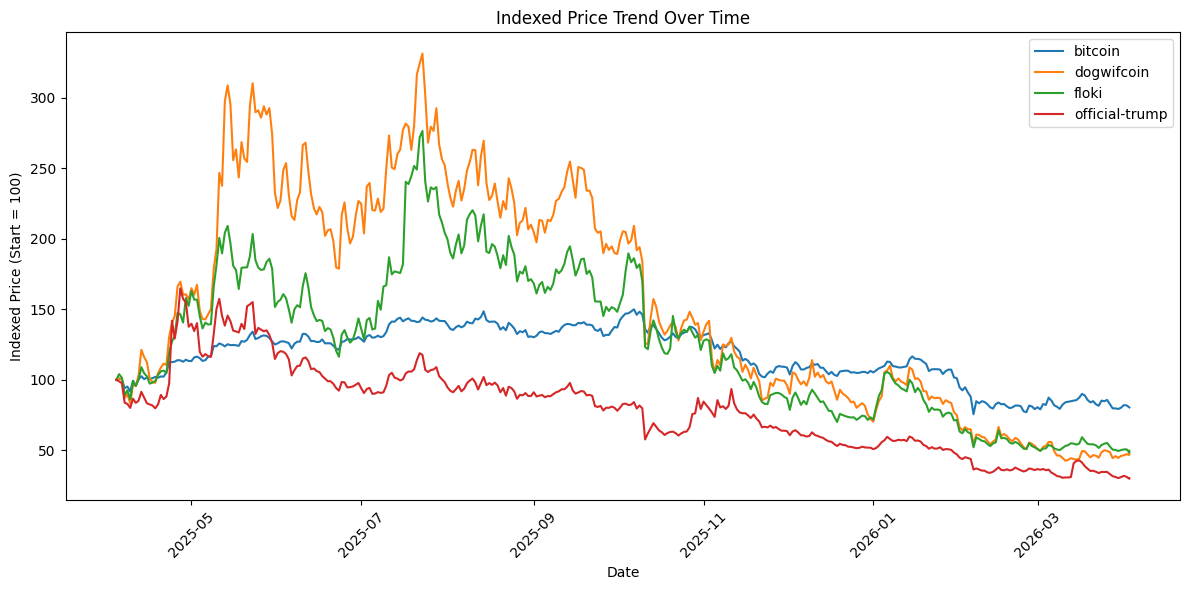

In [ ]:
# Performance of the price over time --> doing a analyzise from 100 so that we can compare the performance of the different coins. 
# The reason for doing this calculus is so that we can compare on a relative basis to each coin.
df = pd.read_csv("../data/interim/master_cleaned.csv")
df["date"] = pd.to_datetime(df["date"])
df = df.sort_values(["coin_id", "date"])

# making indexed price
df["price_index"] = df.groupby("coin_id")["price"].transform(
    lambda s: (s / s.iloc[0]) * 100
)

plt.figure(figsize=(12, 6))

for coin in df["coin_id"].unique():
    coin_df = df[df["coin_id"] == coin]
    plt.plot(coin_df["date"], coin_df["price_index"], label=coin)

plt.title("Indexed Price Trend Over Time")
plt.xlabel("Date")
plt.ylabel("Indexed Price (Start = 100)")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()